# Consistency benchmarks

Quantifying consistency of implemented protocols in terms of dirty reads, synchrony violations, latency and throughput.

Benchmark used: YCSB A, B, high_contention

MONSTER protocol params:

- round_time
- read_retries
- read_offset

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:

async_best_effort = [
    {
        "read_retries": 0,
        "dr_percent": 12184 / 10003905,
        "read_avg": 1070, "read_p99": 1620, "read_p9999": 5100, "read_p100": 12074166,
        "write_avg": 1010, "write_p99": 1370, "write_p999": 4900, "write_p100": 12434906,
        "tput": 881246,
    },
    {
        "read_retries": 1,
        "dr_percent": 796 / 10010651,
        "read_avg": 1070, "read_p99": 1640, "read_p9999": 4700, "read_p100": 12410000,
        "write_avg": 1010, "write_p99": 1340, "write_p999": 4520, "write_p100": 11910000,
        "tput": 881191,
    },
    {
        "read_retries": 10,
        "dr_percent": 341 / 10010651,
        "read_avg": 1080, "read_p99": 1640, "read_p9999": 5350, "read_p100": 11950000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11910000,
        "tput": 878767,
    },
    {
        "read_retries": 100,
        "dr_percent": 212 / 10010651,
        "read_avg": 1080, "read_p99": 1640, "read_p9999": 8060, "read_p100": 11840000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11970000,
        "tput": 876984,
    },
    {
        "read_retries": 1000,
        "dr_percent": 165 / 10010651,
        "read_avg": 1140, "read_p99": 1640, "read_p9999": 8820, "read_p100": 12000000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11970000,
        "tput": 852616,
    },
    {
        "read_retries": 10000,
        "dr_percent": 131 / 10003905,
        "read_avg": 1660, "read_p99": 1630, "read_p9999": 7350, "read_p100": 23000000,
        "write_avg": 1010, "write_p99": 1330, "write_p999": 4650, "write_p100": 11970000,
        "tput": 852616,
    },
]


In [41]:
df = pd.DataFrame(async_best_effort)
df["label"] = "abe"
df

,read_retries,dr_percent,read_avg,read_p99,read_p9999,read_p100,write_avg,write_p99,write_p999,write_p100,tput,label
0,0,0.001218,1070,1620,5100,12074166,1010,1370,4900,12434906,881246,abe
1,1,0.000080,1070,1640,4700,12410000,1010,1340,4520,11910000,881191,abe
2,10,0.000034,1080,1640,5350,11950000,1010,1330,4650,11910000,878767,abe
3,100,0.000021,1080,1640,8060,11840000,1010,1330,4650,11970000,876984,abe
4,1000,0.000016,1140,1640,8820,12000000,1010,1330,4650,11970000,852616,abe
5,10000,0.000013,1660,1630,7350,23000000,1010,1330,4650,11970000,852616,abe


<Axes: xlabel='read_retries'>

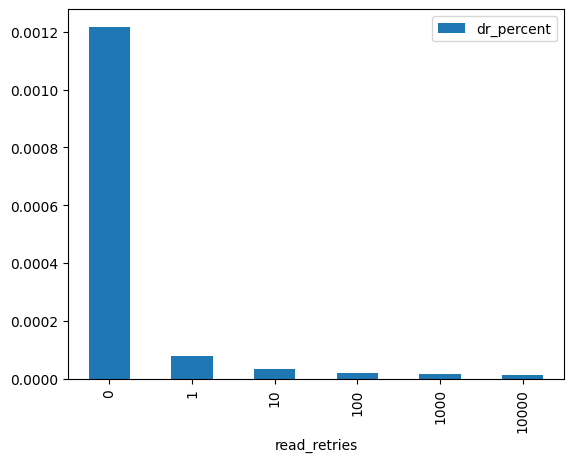

In [37]:
# fig, ax = plt.subplots()
df.plot(x="read_retries", y=["dr_percent"], kind="bar")